In [ ]:
import networkx as nx
import random
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t
import pandas as pd
import random as rnd

In [ ]:
def find_max_independent_set_heuristic(graph):
    best_independent_set = set()  #stores the largest independent set found
    vertices = list(graph.nodes())  #list of vertices in the graph
    #for recording the time
    start_time = time.time ()

    for initial_vertex in vertices:
        independent_set = set()  #independent set for the current iteration
        independent_set.add(initial_vertex)

        #add neighbors of the initial vertex to the independent set if feasible
        neighbors = list(graph.neighbors(initial_vertex))
        for neighbor in neighbors:
            if all(not graph.has_edge(neighbor, node) for node in independent_set):
                independent_set.add(neighbor)

        #update adjacency matrix by removing edges adjacent to nodes in the independent set and their neighbors
        temp_graph = graph.copy()
        nodes_to_remove = set(independent_set)
        for node in independent_set:
            if node in temp_graph:
                nodes_to_remove.update(temp_graph.neighbors(node))
        temp_graph.remove_nodes_from(nodes_to_remove)

        #repeat the improvement process
        while temp_graph.number_of_edges() > 0:
            #find the vertex with the maximum degree
            max_degree_vertex = max(temp_graph.degree, key=lambda x: x[1])[0]

            #add neighbors of the maximum degree vertex if feasible
            neighbors = list(temp_graph.neighbors(max_degree_vertex))
            for neighbor in neighbors:
                if all(not graph.has_edge(neighbor, node) for node in independent_set):
                    independent_set.add(neighbor)

            #update the adjacency matrix
            nodes_to_remove = set(independent_set)
            for node in independent_set:
                if node in temp_graph:
                    nodes_to_remove.update(temp_graph.neighbors(node))
            temp_graph.remove_nodes_from(nodes_to_remove)

        #try to add remaining vertices to the independent set
        for vertex in graph.nodes():
            if vertex not in independent_set and all(
                neighbor not in independent_set for neighbor in graph.neighbors(vertex)
            ):
                independent_set.add(vertex)

        #try shifting vertices to create feasible additions
        for vertex in vertices:
            if vertex not in independent_set:
                neighbors = list(graph.neighbors(vertex))
                for neighbor in neighbors:
                    if neighbor in independent_set and len(neighbors) == 1:
                        independent_set.remove(neighbor)
                        independent_set.add(vertex)
                        break

        #update the best independent set if the current one is larger
        if len(independent_set) > len(best_independent_set):
            best_independent_set = independent_set

    #calculating the total time taken by the algorithm
    end_time = time.time ()
    total_time = end_time - start_time

    return best_independent_set,total_time

def is_independent_set(graph,subset):
    for i in range(len(subset)):
            for j in range(i + 1, len(subset)):
                # Check if there's an edge between any two nodes in the subset
                if graph.has_edge(subset[i], subset[j]):
                    return False
    return True


def find_max_independent_set(graph):
    #for recording the time
    start_time = time.time ()
    max_independent_set = []

    #initialize a subset list containing the empty subset
    subsets = [[]]

    #create a list to store vertices from the graph
    vertices = list(graph.nodes())

    #generate all subsets by adding each vertex to existing subsets
    for vertex in vertices:
        temp_subsets = []

        #add the current vertex to each existing subset to create new subsets
        for subset in subsets:
            temp_subset = subset + [vertex]
            temp_subsets.append(temp_subset)

        #add new subsets to the list of all subsets
        subsets.extend(temp_subsets)

    #iterating over each subset ot find the max
    for subset in subsets:
        #check if the subset is an independent set and the len of the subset is bigger than the max
        if is_independent_set(graph,subset) and len(subset) > len(max_independent_set):
            max_independent_set = subset

    #calculating the total time taken by the algorithm
    end_time = time.time ()
    total_time = end_time - start_time

    return max_independent_set, total_time

def generate_random_graph(num_vertices, edge_probability):
    G = nx.Graph()
    G.add_nodes_from(range(num_vertices))

    for i in range(num_vertices):
        for j in range(i + 1, num_vertices):
            if random.random() < edge_probability:
                G.add_edge(i, j)

    return G

In [ ]:
def run_test():
    graph_sizes = [5, 8, 10, 13, 16, 19, 20, 25]
    edge_probabilities = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    iterations = 30

    results = []

    for size in graph_sizes:
        print(f"Now on the graph with size: {size}")
        quality_ratios = []
        heuristic_runtimes = []
        brute_force_runtimes = []

        for _ in range(iterations):
            rand = np.random.default_rng()
            edge_prob = rand.uniform(low=0,high=1)

            graph = generate_random_graph(size, edge_prob)

            heuristic_set, heuristic_time = find_max_independent_set_heuristic(graph)
            brute_force_set, brute_force_time = find_max_independent_set(graph)

            #calculate success rate
            if len(brute_force_set) > 0:
                quality_ratios.append(len(heuristic_set) / len(brute_force_set))
            else:
                quality_ratios.append(0)

            #record runtimes
            heuristic_runtimes.append(heuristic_time)
            brute_force_runtimes.append(brute_force_time)

        #store aggregated results after 30 iterations
        results.append({
            'size': size,
            'edge_probability': edge_prob,
            'success_rate': np.mean(quality_ratios),
            'heuristic_runtime': np.mean(heuristic_runtimes),
            'brute_force_runtime': np.mean(brute_force_runtimes)
        })

    return results


In [ ]:
results = run_test()

#converting results to DataFrame
results_df = pd.DataFrame(results)

Now on the graph with size: 5
Now on the graph with size: 8
Now on the graph with size: 10
Now on the graph with size: 13
Now on the graph with size: 16
Now on the graph with size: 19
Now on the graph with size: 20
Now on the graph with size: 25


In [22]:
results_df

,size,edge_probability,success_rate,heuristic_runtime,brute_force_runtime
0,5,0.889339,1.000000,0.000490,0.000069
1,8,0.421743,1.000000,0.001270,0.000592
2,10,0.335010,1.000000,0.001185,0.001863
3,13,0.000704,0.993333,0.002275,0.015225
4,16,0.020782,0.995833,0.004476,0.381469
5,19,0.150342,0.991111,0.007635,1.361322
6,20,0.795370,0.993333,0.008128,2.683164
7,25,0.744037,0.975106,0.140118,89.533021


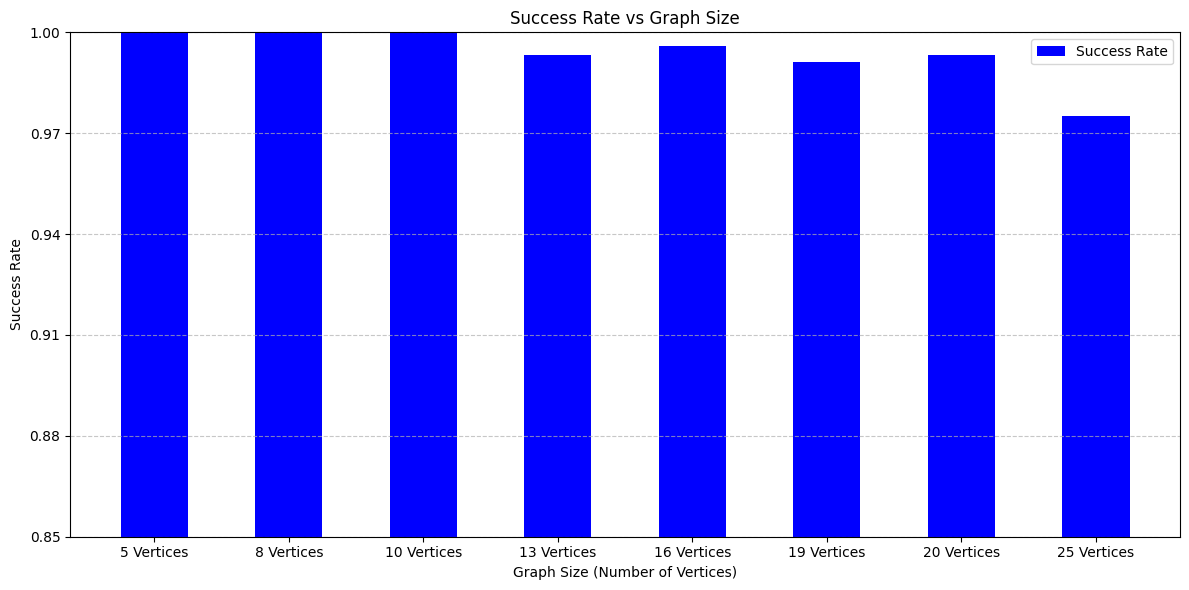

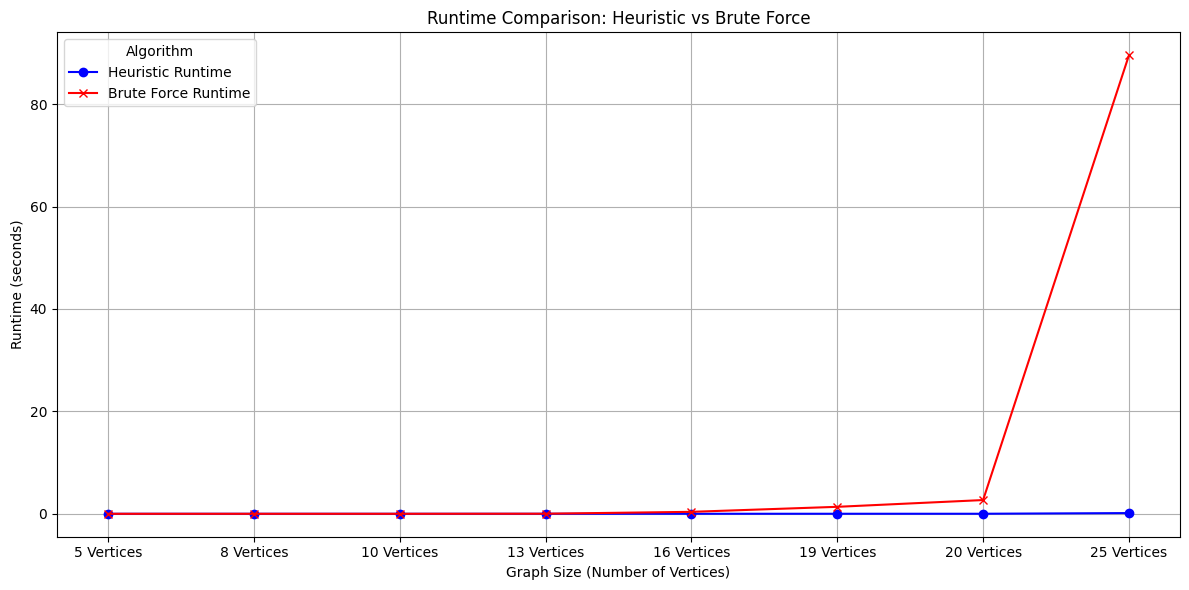

In [ ]:
#success rate
plt.figure(figsize=(12, 6))

#aggregate success rates by graph size
success_rates = results_df.groupby('size')['success_rate'].mean()
graph_sizes = success_rates.index

plt.bar(
    range(len(graph_sizes)),  
    success_rates.values,
    color='blue',
    width=0.5,
    label="Success Rate"
)

plt.xlabel("Graph Size (Number of Vertices)")
plt.ylabel("Success Rate")
plt.title("Success Rate vs Graph Size")
plt.xticks(range(len(graph_sizes)), [f"{size} Vertices" for size in graph_sizes])  
plt.ylim(0.85, 1)  
plt.yticks(np.linspace(0.85, 1, 6))  
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


#runtime comparison
plt.figure(figsize=(12, 6))

#average runtime for heuristic and brute force
heuristic_runtimes = results_df.groupby('size')['heuristic_runtime'].mean()
brute_force_runtimes = results_df.groupby('size')['brute_force_runtime'].mean()

plt.plot(
    range(len(graph_sizes)), 
    heuristic_runtimes.values,
    label="Heuristic Runtime",
    marker='o',
    color='blue'
)
plt.plot(
    range(len(graph_sizes)),  
    brute_force_runtimes.values,
    label="Brute Force Runtime",
    marker='x',
    color='red'
)

plt.xlabel("Graph Size (Number of Vertices)")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime Comparison: Heuristic vs Brute Force")
plt.xticks(range(len(graph_sizes)), [f"{size} Vertices" for size in graph_sizes]) 
plt.legend(title="Algorithm")
plt.grid()
plt.tight_layout()
plt.show()

